
# EDA: KAERI TR-1665 — Non-Uniformly Heated Tubes (`kaeri_tr1665_nonuniform_chf.csv`)

CHF test data for axially non-uniform (cosine-type) heating profiles from
KAERI/TR-1665. The companion `kaeri_tr1665_nonuniform.xml` file carries, per
test, the full axial local-quality profile (`Quality` at each
`QualityPosition`) collapsed to a single row in the flattened CSV — that
profile structure is explored separately below.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/kaeri_tr1665_nonuniform")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SLUG = "kaeri_tr1665_nonuniform"
SLUG_TITLE = "KAERI TR-1665 Non-Uniform Heating"

df = pd.read_csv(DATA_DIR / "kaeri_tr1665_nonuniform_chf.csv")

NUMERIC_COLS = ["Diameter", "Perimeter", "Area", "Length", "Pressure", "Power",
                "MassFlux", "MassFlow", "InletTemperature", "InletEnthalpy",
                "HeatFlux", "CHFLocation", "Quality", "QualityPosition",
                "WallPower", "WallMesh"]
CATEGORICAL_COLS = ["Shape", "Fluid", "Source", "Continuous"]
TARGET_COL = "HeatFlux"

df.head()

,TestID,Diameter,Perimeter,Area,Length,Pressure,Power,MassFlux,MassFlow,InletTemperature,InletEnthalpy,HeatFlux,CHFLocation,Shape,Fluid,Source,Continuous,Quality,QualityPosition,WallPower,WallMesh
0,1,0.01123,0.0353,0.000099,1.83,13790000.0,42979.3,1356.3,0.1343,328.9,1513796.52,665700,0.991,inlet,water,Swenson,yes,-0.045,0.0,0.522,0.046
1,2,0.01123,0.0353,0.000099,1.83,13790000.0,47666.5,1356.3,0.1343,313.9,1418007.48,738300,0.838,inlet,water,Swenson,yes,-0.134,0.0,0.522,0.046
2,3,0.01123,0.0353,0.000099,1.83,13790000.0,42779.1,1356.3,0.1343,329.4,1517258.59,662600,0.762,inlet,water,Swenson,yes,-0.042,0.0,0.522,0.046
3,4,0.01123,0.0353,0.000099,1.83,13790000.0,41145.7,949.4,0.0940,325.7,1492140.53,637300,0.876,inlet,water,Swenson,yes,-0.065,0.0,0.522,0.046
4,5,0.01123,0.0353,0.000099,1.83,13790000.0,48273.4,949.4,0.0940,310.6,1398485.69,747700,0.876,inlet,water,Swenson,yes,-0.152,0.0,0.522,0.046


## 2. Data Quality

In [2]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (888, 21)

Dtypes:
TestID                int64
Diameter            float64
Perimeter           float64
Area                float64
Length              float64
Pressure            float64
Power               float64
MassFlux            float64
MassFlow            float64
InletTemperature    float64
InletEnthalpy       float64
HeatFlux              int64
CHFLocation         float64
Shape                object
Fluid                object
Source               object
Continuous           object
Quality             float64
QualityPosition     float64
WallPower           float64
WallMesh            float64
dtype: object

Missing values per column:
CHFLocation    36
dtype: int64

Duplicate rows: 0


## 3. Descriptive Statistics

In [3]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary.to_csv(OUT_DIR / "summary_stats.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Diameter,888.0,1.371556e-02,5.881121e-03,0.005440,9.730000e-03,1.500000e-02,1.500000e-02,2.830000e-02
Perimeter,888.0,4.308739e-02,1.846965e-02,0.017100,3.060000e-02,4.710000e-02,4.710000e-02,8.890000e-02
Area,888.0,1.748804e-04,1.606636e-04,0.000023,7.435600e-05,1.767100e-04,1.767100e-04,6.290200e-04
Length,888.0,3.114916e+00,2.678069e+00,0.061000,1.000000e+00,1.730000e+00,7.000000e+00,7.000000e+00
Pressure,888.0,8.787330e+06,4.483303e+06,430000.000000,6.862000e+06,1.000000e+07,1.238000e+07,1.800000e+07
Power,888.0,1.352548e+05,8.839042e+04,2331.500000,6.287135e+04,1.235173e+05,1.804374e+05,4.961203e+05
MassFlux,888.0,2.012487e+03,1.266147e+03,328.200000,1.006750e+03,1.912400e+03,2.711550e+03,8.916000e+03
MassFlow,888.0,2.772762e-01,1.887884e-01,0.015100,1.195000e-01,2.645000e-01,4.026000e-01,8.557000e-01
InletTemperature,888.0,2.511384e+02,6.890159e+01,10.700000,2.241000e+02,2.702000e+02,3.000000e+02,3.400000e+02
InletEnthalpy,888.0,1.132179e+06,3.603823e+05,44745.810000,9.620714e+05,1.183422e+06,1.347941e+06,2.477890e+06


## 4. Categorical Value Counts

In [4]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} (n_unique={df[col].nunique(dropna=True)}) ---")
    print(df[col].value_counts(dropna=False).head(15))
    print()

--- Shape (n_unique=14) ---
Shape
middle       185
outlet       119
middle(1)    105
inlet         80
middle(2)     63
Middle        63
N-middle      54
N-inlet       52
middle(3)     47
inlet(2)      40
Middle(2)     33
inlet(1)      22
middle(4)     21
spike          4
Name: count, dtype: int64

--- Fluid (n_unique=1) ---
Fluid
water    888
Name: count, dtype: int64

--- Source (n_unique=11) ---
Source
Becker        266
Lee(1966)     221
Lee(1963)     105
Swenson        61
Todreas        58
Zenkevich      54
Bertoletti     48
Lee(1965)      40
Casterline     20
Kinoshita       9
Keeys           6
Name: count, dtype: int64

--- Continuous (n_unique=2) ---
Continuous
yes    721
no     167
Name: count, dtype: int64



## 5. Univariate Distributions

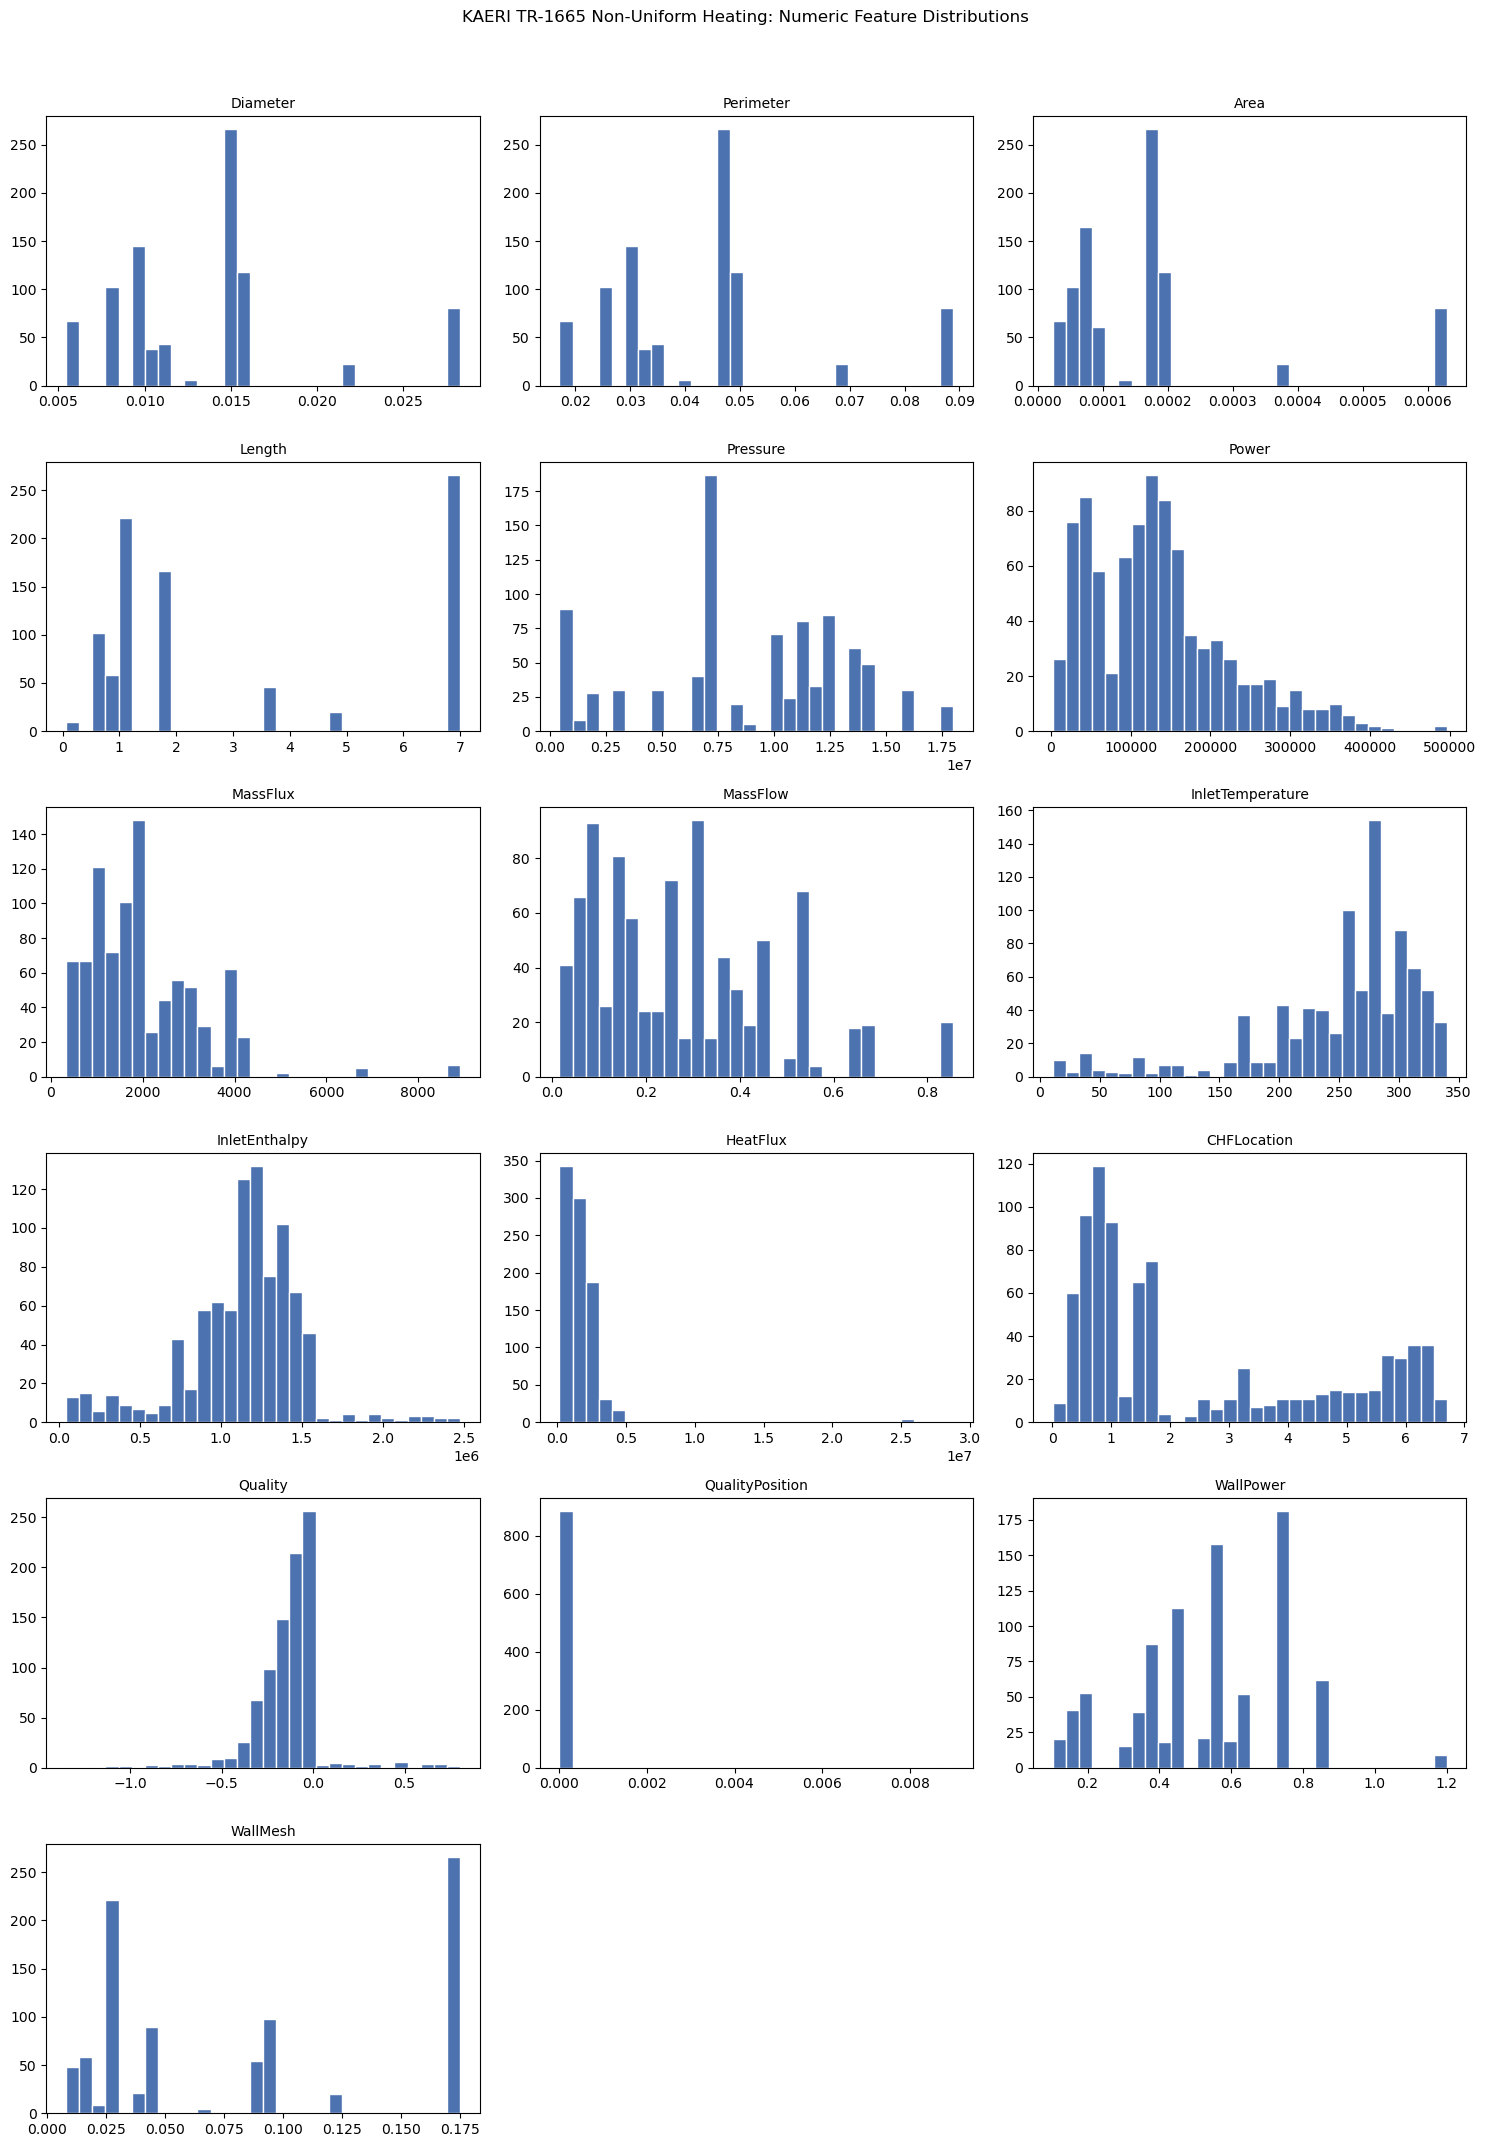

In [5]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: Numeric Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Scan (IQR, z-score)

In [6]:
iqr_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_rows.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s) if len(s) else np.nan,
    })
iqr_table = pd.DataFrame(iqr_rows).set_index("column")
iqr_table.to_csv(OUT_DIR / "iqr_outlier_summary.csv")
iqr_table

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
column,,,,,,,
Diameter,9.730000e-03,1.500000e-02,5.270000e-03,1.825000e-03,2.290500e-02,81,9.121622
Perimeter,3.060000e-02,4.710000e-02,1.650000e-02,5.850000e-03,7.185000e-02,81,9.121622
Area,7.435600e-05,1.767100e-04,1.023540e-04,-7.917500e-05,3.302410e-04,103,11.599099
Length,1.000000e+00,7.000000e+00,6.000000e+00,-8.000000e+00,1.600000e+01,0,0.000000
Pressure,6.862000e+06,1.238000e+07,5.518000e+06,-1.415000e+06,2.065700e+07,0,0.000000
Power,6.287135e+04,1.804374e+05,1.175660e+05,-1.134777e+05,3.567865e+05,22,2.477477
MassFlux,1.006750e+03,2.711550e+03,1.704800e+03,-1.550450e+03,5.268750e+03,12,1.351351
MassFlow,1.195000e-01,4.026000e-01,2.831000e-01,-3.051500e-01,8.272500e-01,20,2.252252
InletTemperature,2.241000e+02,3.000000e+02,7.590000e+01,1.102500e+02,4.138500e+02,59,6.644144


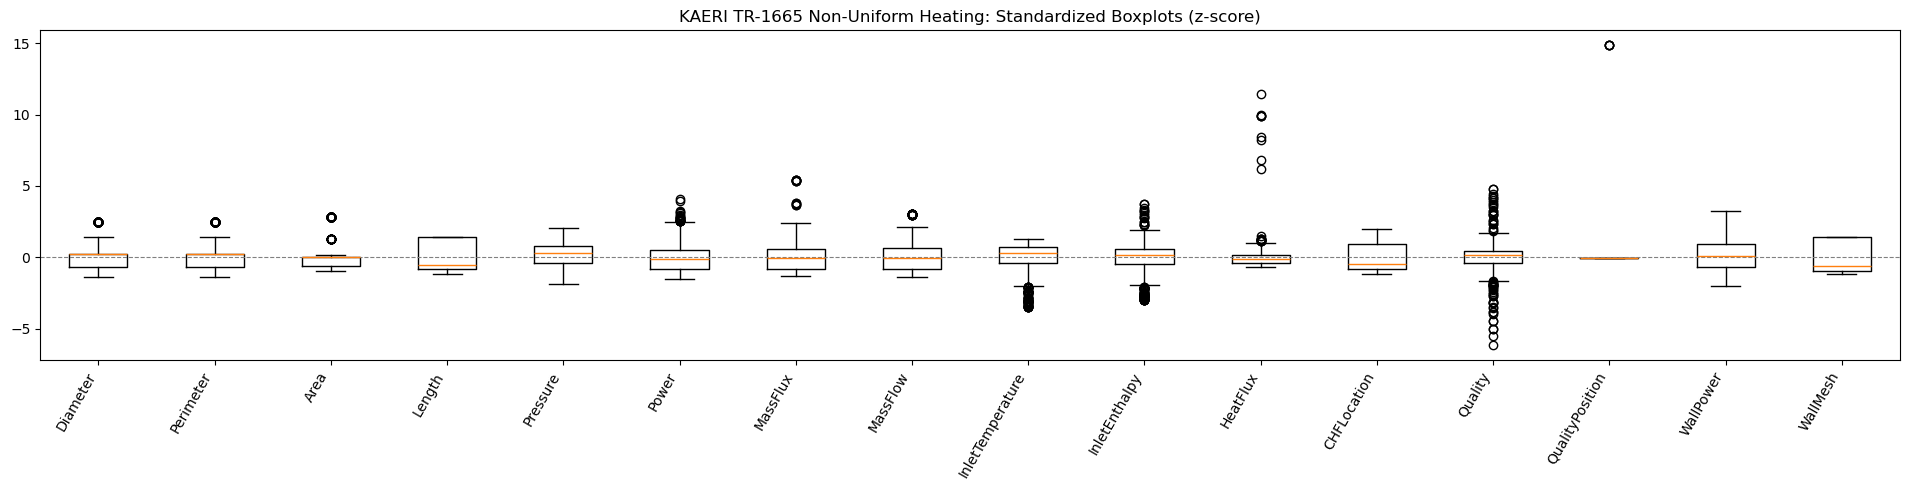

In [7]:
z = df[NUMERIC_COLS].apply(lambda s: (s - s.mean()) / s.std())
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(NUMERIC_COLS)), 5))
ax.boxplot([z[c].dropna() for c in NUMERIC_COLS])
ax.set_xticklabels(NUMERIC_COLS, rotation=60, ha="right")
ax.set_title(f"{SLUG_TITLE}: Standardized Boxplots (z-score)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplots_standardized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Structure

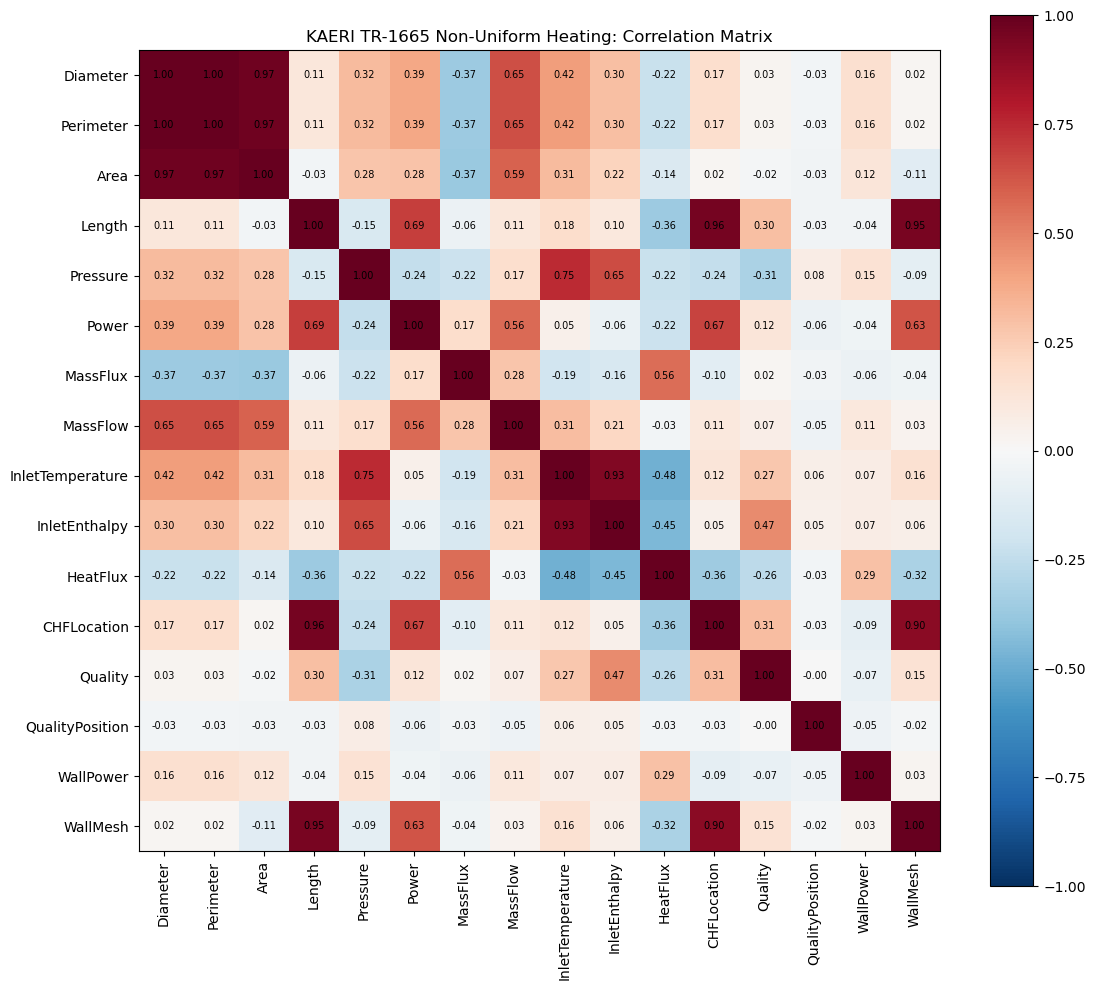

In [8]:
corr = df[NUMERIC_COLS].corr()
corr.to_csv(OUT_DIR / "correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(0.6 * len(NUMERIC_COLS) + 2, 0.6 * len(NUMERIC_COLS) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=90)
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title(f"{SLUG_TITLE}: Correlation Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Target vs. Features

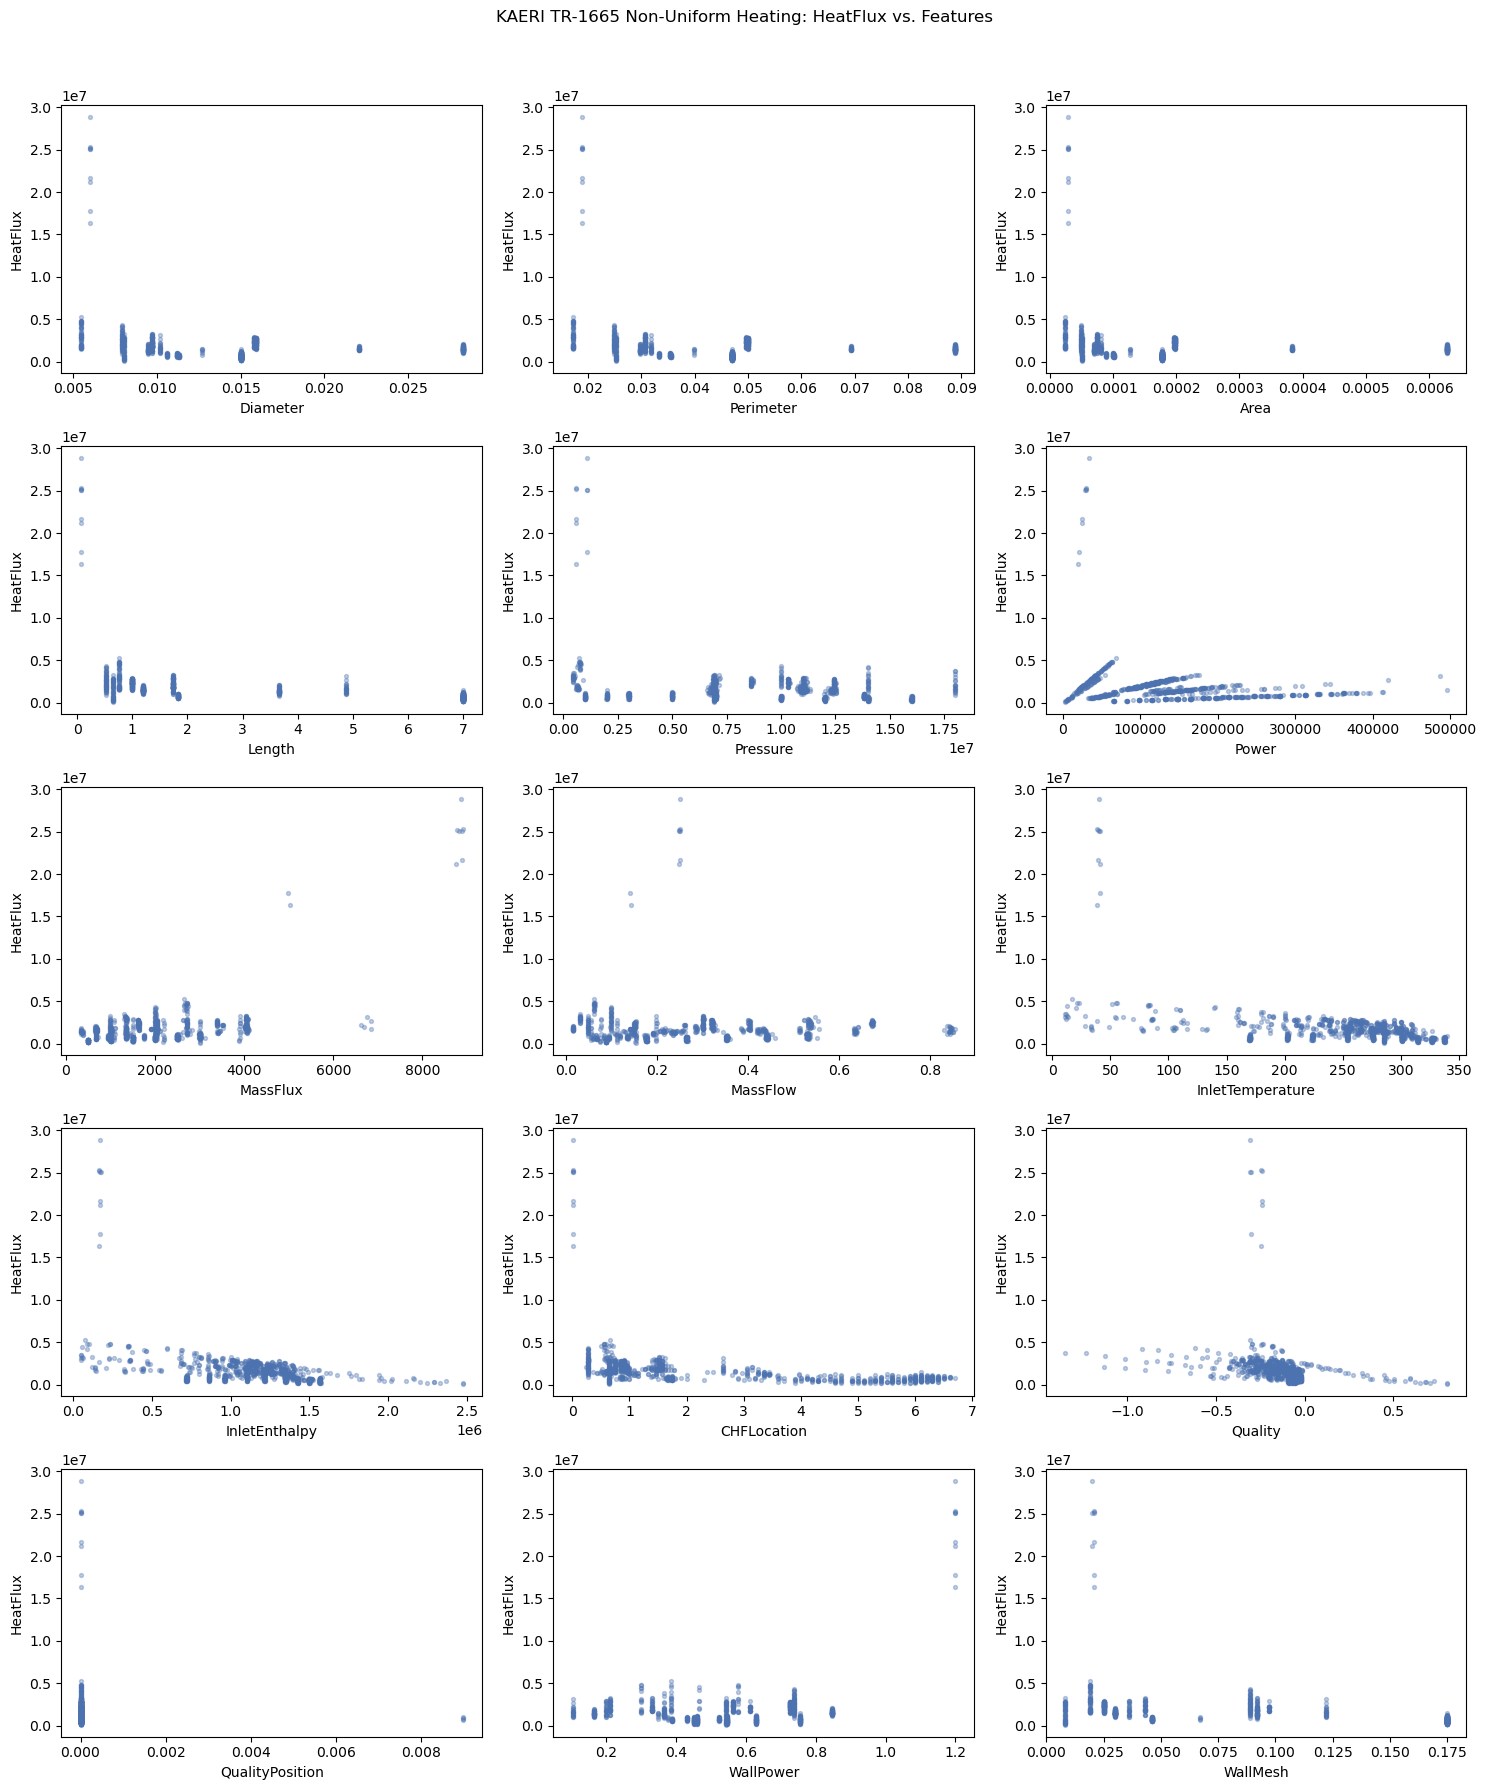

In [9]:
feature_cols = [c for c in NUMERIC_COLS if c != TARGET_COL]
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[TARGET_COL], s=8, alpha=0.35, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: {TARGET_COL} vs. Features", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Target by Category

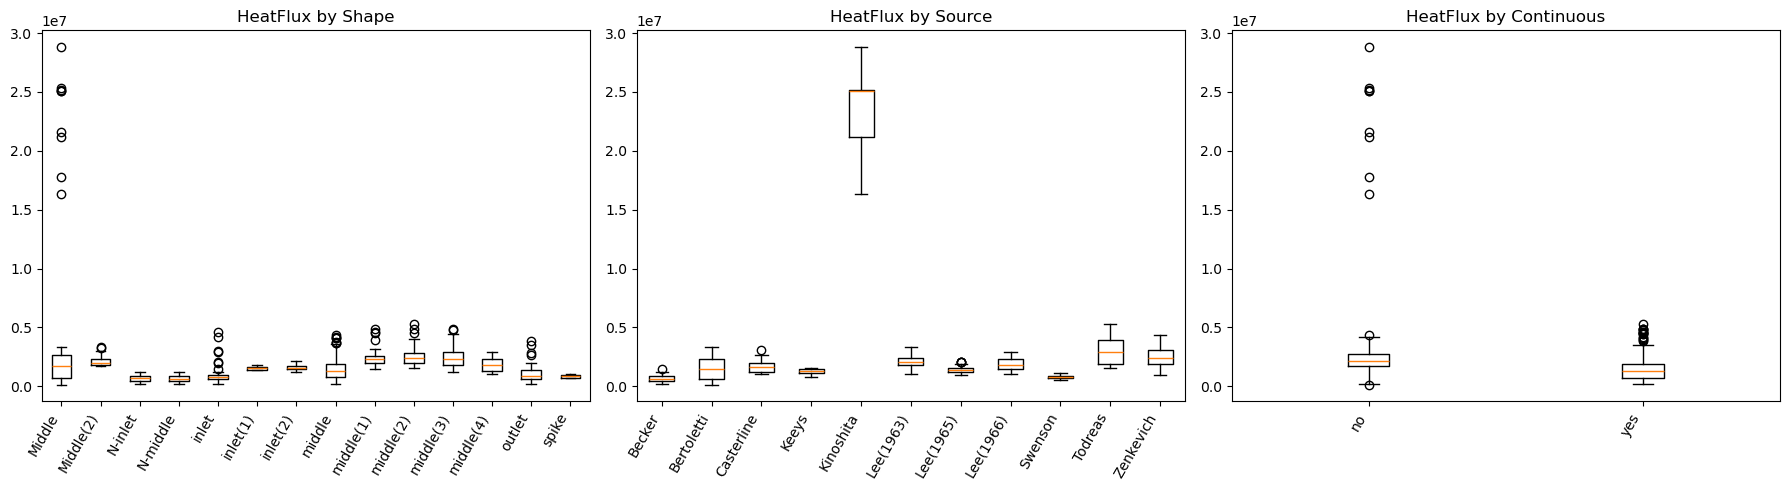

In [10]:
cat_cols_plot = [c for c in CATEGORICAL_COLS
                 if 2 <= df[c].nunique(dropna=True) <= 15]
if cat_cols_plot:
    fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(6 * len(cat_cols_plot), 5), squeeze=False)
    axes = axes[0]
    for ax, col in zip(axes, cat_cols_plot):
        groups = [g[TARGET_COL].dropna().values for _, g in df.groupby(col)]
        labels = [str(k) for k, _ in df.groupby(col)]
        ax.boxplot(groups)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"{TARGET_COL} by {col}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.")


## 10. Axial Local-Quality Profiles (from `kaeri_tr1665_nonuniform.xml`)

Each test in the XML repeats the `Quality`/`QualityPosition` tags once per
axial measurement location, i.e. the CHF-location `Quality`/`QualityPosition`
columns in the CSV are only the *last* value of a full axial profile. This
section reconstructs those profiles.


In [11]:
import xml.etree.ElementTree as ET

tree = ET.parse(DATA_DIR / "kaeri_tr1665_nonuniform.xml")
profiles = []
for ds in tree.getroot().findall("dataset"):
    test_id = ds.find("TestID").text
    qualities = [float(q.text) for q in ds.findall("Quality")]
    positions = [float(p.text) for p in ds.findall("QualityPosition")]
    profiles.append({"TestID": test_id, "n_points": len(qualities),
                      "qualities": qualities, "positions": positions})

profiles_df = pd.DataFrame(profiles)
profiles_df["n_points"].describe()

count    888.000000
mean      48.114865
std        7.435122
min       19.000000
25%       51.000000
50%       51.000000
75%       51.000000
max       51.000000
Name: n_points, dtype: float64

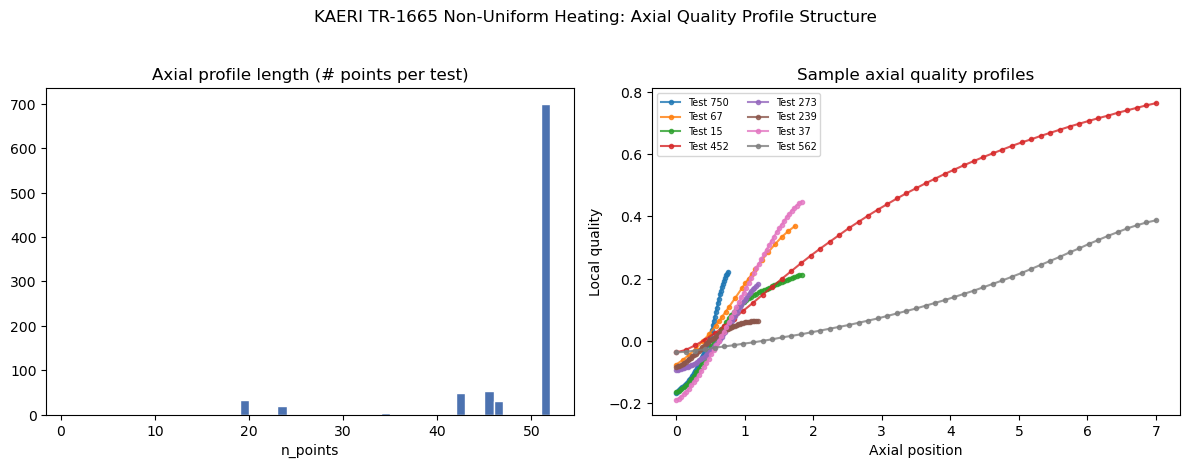

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(profiles_df["n_points"], bins=range(1, profiles_df["n_points"].max() + 2),
             color="#4C72B0", edgecolor="white")
axes[0].set_title("Axial profile length (# points per test)")
axes[0].set_xlabel("n_points")

rng = np.random.default_rng(0)
sample_idx = rng.choice(len(profiles_df), size=min(8, len(profiles_df)), replace=False)
for i in sample_idx:
    row = profiles_df.iloc[i]
    axes[1].plot(row["positions"], row["qualities"], marker="o", markersize=3,
                 alpha=0.8, label=f"Test {row['TestID']}")
axes[1].set_xlabel("Axial position")
axes[1].set_ylabel("Local quality")
axes[1].set_title("Sample axial quality profiles")
axes[1].legend(fontsize=7, ncol=2)

fig.suptitle(f"{SLUG_TITLE}: Axial Quality Profile Structure", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "axial_quality_profiles.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Takeaways

- `HeatFlux` at the reported `CHFLocation` is the target; `Quality` /
  `QualityPosition` in the flat CSV are single (CHF-location) snapshots of a
  richer axial profile that only exists in the XML.
- Non-uniform heating means `Shape` (e.g. `inlet`, cosine-peak location) is an
  important categorical driver of where CHF occurs along the tube — check the
  target-by-category plot above.
- As with the uniform-heating file, `Fluid`/`Source` are constant
  (`water`/`Swenson`) and carry no discriminative signal here.
